### Analyze trips purposes
The following notebook aims to understand the reasons behind the usage of e-scooters. 

To achieve this result, it first use **pyrosm** to collect POI in Trento, it groups them by purpose/similar aim of the POI, creating *11 primary categories* (leisure, public_services, building, education, food, transport, financial, healthcare, office, shop, and tourism) plus one, called *multiple*, representing the belonging to multiple categories, each with several sub-labels. 
The geometries of the POI are then considered. Some geometries returned from pyrosm are points, other polygons or multipolygons: for polygons and multipolygons, the points on their external boundaries are extracted, in order to use them to compute the distance between the e-scooters trips destination and the POI location. The dataset is finally re-built so that each record contains a single point.

Once the POIs dataset is ready, some cleaning procedure is persue on the map-matched trips dataset (`mm_wayID_speed_name.parquet`): extreme values are removed (trips from the first and last 5% quantile, namely very short trips, which were probably done just for fun and not to reach a particular place, and anomalously long trips). This is done to reduce noises in the dataset.
Moreover, trips ending inside the areas of agreed stops (*“aree di sosta convenzionata”*), established by the municipality and granting discounts, are also removed, since people probably stopped there for cheaper price, rather than because their destination was exactly in the surroundings. To implement an efficient research of the points within these areas, advantage of **R-Tree** was taken, using spatial indexes to perform the computation in a fast way.

Finally, **SciPy.spatial.KDTree** was used to efficiently find the nearest POI to origin and destination of each e-scooter trip (nearest neighbors = 1). It returns two arrays, one with indexes and one with the distances from the nearest neighbour. The trips dataset is then augmented adding, for both the starting point and the destination point, a column with the index of the closest POI in the pois dataset (to be able to link the two datasets), the distance from the nearest POI, and its primary category.
The distances between a trip destination and its closest POI help in establishing the likelihood of the trip purpose: the greater the distance, the less likely the inferred aim of the trip. For this reason, a thresholding operation on the distance is performed.

As a conclusion, a detailed study of trips purposes and a further differentiation within the primary categories can be made.

### References:
- [pyrosm documentation](https://pyrosm.readthedocs.io/en/latest/)
- [Wiki OSM, primary features](https://wiki.openstreetmap.org/wiki/Map_features#Primary_features)
- [boost point-in-polygon using spatial index (R-Tree)](https://autogis-site.readthedocs.io/en/latest/notebooks/L3/05_spatial_index.html)
- [SciPy.spatial.KDTree documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html)
- [Nearest Neighbors and KD-trees](https://caam37830.github.io/book/08_geometry/nearestneighbor.html)

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
import requests
import pyrosm
import shapely
import pyproj as proj
from scipy.spatial import KDTree
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Create POI dataset

In [12]:
# Download POI data:
# request data for POI of Trento in PBF format

# uncomment to donwload
'''
trento_download_pbf_url = "https://osmit-estratti.wmcloud.org/dati/poly/comuni/pbf/022205_Trento_poly.osm.pbf"
r = requests.get(trento_download_pbf_url, allow_redirects=True)
open('trento.pbf', 'wb').write(r.content)
'''

'\ntrento_download_pbf_url = "https://osmit-estratti.wmcloud.org/dati/poly/comuni/pbf/022205_Trento_poly.osm.pbf"\nr = requests.get(trento_download_pbf_url, allow_redirects=True)\nopen(\'trento.pbf\', \'wb\').write(r.content)\n'

In [2]:
# use pyrosm to read these data
osm = pyrosm.OSM("../produced_datasets/trip_purpose_data/trento.pbf")
osm.conf.tags.available # primary features/cateogories of POI

['aerialway',
 'aeroway',
 'amenity',
 'boundary',
 'building',
 'craft',
 'emergency',
 'geological',
 'highway',
 'historic',
 'landuse',
 'leisure',
 'natural',
 'office',
 'power',
 'public_transport',
 'railway',
 'route',
 'place',
 'shop',
 'tourism',
 'waterway']

In [3]:
osm.conf.tags.amenity # each primary category contains sub-categories of tags

['addr:city',
 'addr:country',
 'addr:full',
 'addr:housenumber',
 'addr:housename',
 'addr:postcode',
 'addr:place',
 'addr:street',
 'email',
 'name',
 'opening_hours',
 'operator',
 'phone',
 'ref',
 'url',
 'website',
 'yes',
 'amenity',
 'arts_centre',
 'atm',
 'bank',
 'bicycle_parking',
 'bicycle_rental',
 'bicycle_repair_station',
 'bar',
 'bbq',
 'biergarten',
 'brothel',
 'building',
 'building:levels',
 'bureau_de_change',
 'bus_station',
 'bus_stop',
 'cafe',
 'car_rental',
 'car_repair',
 'car_sharing',
 'car_wash',
 'casino',
 'charging_station',
 'childcare',
 'cinema',
 'clinic',
 'college',
 'dentist',
 'doctors',
 'driving_school',
 'drinking_water',
 'fast_food',
 'ferry_terminal',
 'fire_station',
 'food_court',
 'fountain',
 'fuel',
 'gambling',
 'hospital',
 'ice_cream',
 'internet_access',
 'kindergarten',
 'landuse',
 'language_school',
 'library',
 'music_school',
 'nightclub',
 'nursing_home',
 'office',
 'operator',
 'parking',
 'pharmasy',
 'planetarium',
 '

In [4]:
# get POIs in a dataframe, selecting the needed categories
custom_filter = {'building':['residential', 'commercial', 'government', 'public'], # buildings
'amenity': ['place_of_worship', # buildings
'college', 'kidergarden', 'school', 'university', 'driving_school', 'language_school', 'library', 'toy_library', 'music_school', # education
'bar', 'cafe', 'restaurant', 'biergarten', 'fast_food', 'food_court', 'ice_cream', 'pub', # Sustenance
'taxi', 'parking', 'parking_space', 'motorcycle_parking', 'car_sharing', 'car_rental', 'bus_station', 'bicycle_parking', # transport
'atm', 'bank', 'bureau_de_change', # finantial
'baby_hatch', 'clinic', 'dentist', 'doctors', 'hospital', 'nursing_home', 'pharmacy', 'social_facility', 'veterinary', # healthcare
'arts_centre', 'casino', 'cinema', 'community_centre', 'conference_centre', 'event_centre', 'events_venue', 'fountain', 'gambling', 'nightclub', 'planetarium', 'public_bookcase', 'social_centre', 'studio', 'theatre', 'internet_cafe', # entertainment
'courthouse', 'fire_station', 'police', 'post_box', 'post_depot', 'post_office', 'prison', 'ranger_station', 'townhall'], # public_services 
'leisure': True, 
'office': True, # yes means generic office type
'shop': True, # yes means unspecified shop type
'tourism': True # yes means tourist point of interest, described by some other tag
} 
pois = osm.get_pois(custom_filter=custom_filter)
pois.columns

Index(['id', 'changeset', 'lon', 'timestamp', 'tags', 'lat', 'version',
       'addr:city', 'addr:country', 'addr:housenumber', 'addr:housename',
       'addr:postcode', 'addr:place', 'addr:street', 'email', 'name',
       'opening_hours', 'operator', 'phone', 'ref', 'url', 'website',
       'building', 'amenity', 'craft', 'internet_access', 'office', 'shop',
       'source', 'start_date', 'wikipedia', 'atm', 'bicycle_parking', 'bar',
       'cafe', 'drinking_water', 'ice_cream', 'parking', 'social_facility',
       'fitness_station', 'leisure', 'outdoor_seating', 'playground',
       'consulting', 'government', 'religion', 'bicycle', 'clothes',
       'fireplace', 'lottery', 'model', 'organic', 'tobacco', 'wholesale',
       'guest_house', 'information', 'tourism', 'geometry', 'osm_type',
       'building:levels', 'building:use', 'height', 'landuse', 'company',
       'levels'],
      dtype='object')

In [5]:
pois = pois[['lon', 'lat', 'geometry', 'name', 'wikipedia', 'building', 'amenity', 'office', 'leisure', 'shop', 'tourism']]

In [6]:
# add wikipedia name to name column
for i in range(len(pois)):
    if pd.notna(pois.at[i, 'wikipedia']): 
        if pd.notna(pois.at[i, 'name']):
            pois.at[i, 'name'] = pois.at[i, 'wikipedia'].split(':')[1]
        else:
            pois.at[i, 'name'] = pois.at[i, 'name'] + ', ' + pois.at[i, 'wikipedia'].split(':')[1]
pois = pois.drop(['wikipedia'], axis=1)

In [7]:
for i in range(len(pois)):
    if pois.at[i, 'office'] == 'yes':
        pois.at[i, 'office'] = 'generic office place'
    if pois.at[i, 'shop'] == 'yes':
        pois.at[i, 'shop'] = 'unspecified shop'
    if pois.at[i, 'tourism'] == 'yes':
        pois.at[i, 'tourism'] = 'tourist POI'
    if pois.at[i, 'building'] == 'yes':
        pois.at[i, 'building'] = 'generic building'

Create primary categories:

In [8]:
lst_cols = list(pois.columns[4:])
lst_cols

['building', 'amenity', 'office', 'leisure', 'shop', 'tourism']

In [9]:
all_categories = []
for i in range(len(pois)):
    detailed_category = []
    for cat in lst_cols:
        if pd.notna(pois.at[i, cat]) and pois.at[i, cat] not in detailed_category:
            detailed_category.append(pois.at[i, cat])
    all_categories.append(detailed_category)
pois['tags'] = all_categories

In [10]:
pois

,lon,lat,geometry,name,building,amenity,office,leisure,shop,tourism,tags
0,11.140261,46.071609,POINT (11.14026 46.07161),Farmacia Comunale San Donà,None,pharmacy,None,None,None,None,[pharmacy]
1,11.140469,46.071827,POINT (11.14047 46.07183),Pizzeria Al Villaggio,None,restaurant,None,None,None,None,[restaurant]
2,11.139650,46.070690,POINT (11.13965 46.07069),Famiglia Cooperativa,None,None,None,None,supermarket,None,[supermarket]
3,11.153923,46.065948,POINT (11.15392 46.06595),Poste Italiane,None,post_office,None,None,None,None,[post_office]
4,11.140263,46.109612,POINT (11.14026 46.10961),Il bosco incantato,None,restaurant,None,None,None,None,[restaurant]
...,...,...,...,...,...,...,...,...,...,...,...
5385,NaN,NaN,"MULTIPOLYGON (((11.12422 46.09303, 11.12432 46...",Parco Gaban,None,None,None,park,None,None,[park]
5386,NaN,NaN,"POLYGON ((11.09090 46.11154, 11.09221 46.11174...",None,None,parking,None,None,None,None,[parking]
5387,NaN,NaN,"POLYGON ((11.12892 46.00331, 11.12892 46.00333...",None,None,None,None,garden,None,None,[garden]
5388,NaN,NaN,"MULTIPOLYGON (((11.14932 46.06766, 11.14935 46...","Polo Scientifico e Tecnologico ""Polo Ferrari""",None,university,None,None,None,None,[university]


In [11]:
primary_categories = {
'leisure': ['pitch', 'playground', 'sports_centre', 'fitness_centre',
       'club', 'dance', 'tanning_salon', 'picnic_table', 'social_club',
       'adult_gaming_centre', 'park', 'slipway', 'fitness_station',
       'nature_reserve', 'track', 'garden', 'arts_centre', 'casino', 'cinema', 'community_centre', 'conference_centre', 'event_centre', 
       'events_venue', 'fountain', 'gambling', 'nightclub', 'planetarium', 'public_bookcase', 'social_centre', 'studio', 'theatre', 'internet_cafe'], 
'public_services': ['courthouse', 'fire_station', 'police', 'post_box', 'post_depot', 'post_office', 'prison', 'ranger_station', 'townhall'], 
'building':['residential', 'commercial', 'public', 'place_of_worship'],
'education': ['college', 'kidergarden', 'school', 'university', 'driving_school', 'language_school', 'library', 'toy_library', 'music_school'],
'food': ['bar', 'cafe', 'coffee', 'restaurant', 'biergarten', 'fast_food', 'food_court', 'ice_cream', 'pub', 'supermarket','bakery', 'pastry', 'kiosk', 'greengrocer','tea', 'pasta', 'seafood', 'butcher'],
'transport': ['taxi', 'parking', 'parking_space', 'motorcycle_parking', 'car_sharing', 'car_rental', 'bus_station', 'bicycle_parking'],
'finantial': ['atm', 'bank', 'bureau_de_change'],
'healthcare': ['baby_hatch', 'clinic', 'dentist', 'doctors', 'hospital', 'nursing_home', 'pharmacy', 'social_facility', 'veterinary', 'optician'],
'office': ['government', 'accountant', 'estate_agent',
       'political_party', 'ngo', 'administrative', 'insurance',
       'employment_agency', 'telecommunication',
       'educational_institution', 'company', 'notary', 'architect',
       'association', 'courier', 'energy_supplier', 'therapist',
       'newspaper', 'union', 'graphic_design', 'it', 'lawyer',
       'construction_company', 'generic office place',
       'advertising_agency', 'IT', 'consulenza_brevettuale', 'consulting',
       'foundation', 'research'],
'shop': ['newsagent', 'bag', 'clothes', 'jewelry','convenience', 'car_repair', 'electronics', 'computer',
       'hairdresser', 'florist', 'herbalist', 'tyres', 'laundry', 'books', 'shoes',
       'cosmetics', 'chemist', 'beauty', 'dry_cleaning',
       'furniture', 'sports', 'tobacco', 'boutique', 'curtain', 'deli',
       'outdoor', 'paint', 'hearing_aids', 'stationery', 'bicycle',
       'hardware', 'pet', 'travel_agency', 'perfumery', 'anime',
       'weapons', 'antiques', 'money_lender', 'trade', 'tailor',
       'copyshop', 'mobile_phone', 'interior_decoration', 'toys',
       'doityourself', 'craft', 'car', 'gift', 'beverages',
       'fashion_accessories', 'houseware', 'e-cigarette', 'hifi',
       'art', 'fabric', 'confectionery', 'erotic',
       'department_store', 'watches', 'tattoo', 'clothes;food', 'hunting',
       'kitchen', 'bed', 'motorcycle', 'variety_store', 'second_hand',
       'pawnbroker', 'frame', 'unspecified shop', 'musical_instrument',
       'farm', 'party', 'photo', 'vacant', 'funeral_directors', 'model',
       'carpet', 'camera', 'printer_cartridges', 'video_games',
       'garden_centre', 'car_parts', 'bathroom_furnishing', 'lottery',
       'pet_grooming', 'wine', 'music', 'baby_goods', 'video', 'candles',
       'storage_rental', 'radiotechnics', 'tiles', 'wholesale',
       'appliance', 'gas', 'car;car_repair'],
'tourism': ['museum', 'information', 'viewpoint', 'picnic_site',
       'attraction', 'hotel', 'hostel', 'guest_house', 'artwork',
       'apartment', 'alpine_hut']
}

In [12]:
primary_category = []
for lst in pois.tags:
    if len(lst) > 1:
        pc=[]
        for el in range(len(lst)):
            for key in primary_categories.keys():
                if lst[el] in primary_categories[key]:
                    pc.append(key)
        if len(set(pc))==1:
            primary_category.append(pc[0])
        else:
            primary_category.append('multiple')
    else:
        for key in primary_categories.keys():
            if lst[0] in primary_categories[key]:
                primary_category.append(key)

In [13]:
pois['primary_category'] = primary_category
pois

,lon,lat,geometry,name,building,amenity,office,leisure,shop,tourism,tags,primary_category
0,11.140261,46.071609,POINT (11.14026 46.07161),Farmacia Comunale San Donà,None,pharmacy,None,None,None,None,[pharmacy],healthcare
1,11.140469,46.071827,POINT (11.14047 46.07183),Pizzeria Al Villaggio,None,restaurant,None,None,None,None,[restaurant],food
2,11.139650,46.070690,POINT (11.13965 46.07069),Famiglia Cooperativa,None,None,None,None,supermarket,None,[supermarket],food
3,11.153923,46.065948,POINT (11.15392 46.06595),Poste Italiane,None,post_office,None,None,None,None,[post_office],public_services
4,11.140263,46.109612,POINT (11.14026 46.10961),Il bosco incantato,None,restaurant,None,None,None,None,[restaurant],food
...,...,...,...,...,...,...,...,...,...,...,...,...
5385,NaN,NaN,"MULTIPOLYGON (((11.12422 46.09303, 11.12432 46...",Parco Gaban,None,None,None,park,None,None,[park],leisure
5386,NaN,NaN,"POLYGON ((11.09090 46.11154, 11.09221 46.11174...",None,None,parking,None,None,None,None,[parking],transport
5387,NaN,NaN,"POLYGON ((11.12892 46.00331, 11.12892 46.00333...",None,None,None,None,garden,None,None,[garden],leisure
5388,NaN,NaN,"MULTIPOLYGON (((11.14932 46.06766, 11.14935 46...","Polo Scientifico e Tecnologico ""Polo Ferrari""",None,university,None,None,None,None,[university],education


In [14]:
tag1 = []
tag2 = []
tag3 = []
for lst in pois.tags:
    tag1.append(lst[0])
    if len(lst)>1:
        tag2.append(lst[1])
        if len(lst)>2:
            tag3.append(lst[2])
        else:
            tag3.append(None)
    else:
        tag2.append(None)
        tag3.append(None)

In [15]:
pois['tag1'] = tag1
pois['tag2'] = tag2
pois['tag3'] = tag3
pois = pois[['lon', 'lat', 'geometry', 'name', 'tag1', 'tag2', 'tag3', 'tags', 'primary_category']]

In [16]:
pois

,lon,lat,geometry,name,tag1,tag2,tag3,tags,primary_category
0,11.140261,46.071609,POINT (11.14026 46.07161),Farmacia Comunale San Donà,pharmacy,None,None,[pharmacy],healthcare
1,11.140469,46.071827,POINT (11.14047 46.07183),Pizzeria Al Villaggio,restaurant,None,None,[restaurant],food
2,11.139650,46.070690,POINT (11.13965 46.07069),Famiglia Cooperativa,supermarket,None,None,[supermarket],food
3,11.153923,46.065948,POINT (11.15392 46.06595),Poste Italiane,post_office,None,None,[post_office],public_services
4,11.140263,46.109612,POINT (11.14026 46.10961),Il bosco incantato,restaurant,None,None,[restaurant],food
...,...,...,...,...,...,...,...,...,...
5385,NaN,NaN,"MULTIPOLYGON (((11.12422 46.09303, 11.12432 46...",Parco Gaban,park,None,None,[park],leisure
5386,NaN,NaN,"POLYGON ((11.09090 46.11154, 11.09221 46.11174...",None,parking,None,None,[parking],transport
5387,NaN,NaN,"POLYGON ((11.12892 46.00331, 11.12892 46.00333...",None,garden,None,None,[garden],leisure
5388,NaN,NaN,"MULTIPOLYGON (((11.14932 46.06766, 11.14935 46...","Polo Scientifico e Tecnologico ""Polo Ferrari""",university,None,None,[university],education


Where there is a polygon or multipolygon, get the coordinates of the enxterior boundaries, and convert all cordinates to epsg:32632 (meters)

In [17]:
# setup start and end projection
crs_lonlat = proj.Proj(init='epsg:4326') # start projection
crs_meters = proj.Proj(init='epsg:32632') # meters 32632 italia utm 32n wgs84

c = []
for i in pois.geometry:
    coords = []
    if type(i)==shapely.geometry.polygon.Polygon:
        # cicle on exterior coordinates of polygon:
        for pt in i.exterior.coords[:-1]: # the first and last points are the same, thus do not take the last one
            coords.append(proj.transform(crs_lonlat, crs_meters, pt[0], pt[1])) # change crs (meters)

    elif type(i)==shapely.geometry.multipolygon.MultiPolygon:
        multipoly = i.geoms # list of all polygons in multipolygon
        poly_coords = []
        for poly in multipoly:
            # exterior coordinates of polygon:
            poly_coords.extend(poly.exterior.coords[:-1]) 
        for pt in poly_coords:
            coords.append(proj.transform(crs_lonlat, crs_meters, pt[0], pt[1])) # change crs (meters)
        
    elif type(i)==shapely.geometry.point.Point:
        coords.append(proj.transform(crs_lonlat, crs_meters, i.x, i.y)) # change crs (meters)

    c.append(coords)
        

pois['coords'] = c

In [18]:
len(pois.geometry.unique()) == len(pois) # no geometry is repeated

True

In [19]:
pois

,lon,lat,geometry,name,tag1,tag2,tag3,tags,primary_category,coords
0,11.140261,46.071609,POINT (11.14026 46.07161),Farmacia Comunale San Donà,pharmacy,None,None,[pharmacy],healthcare,"[(665510.0286843351, 5104230.722341995)]"
1,11.140469,46.071827,POINT (11.14047 46.07183),Pizzeria Al Villaggio,restaurant,None,None,[restaurant],food,"[(665525.4554475527, 5104255.313606368)]"
2,11.139650,46.070690,POINT (11.13965 46.07069),Famiglia Cooperativa,supermarket,None,None,[supermarket],food,"[(665465.5784098682, 5104127.308233347)]"
3,11.153923,46.065948,POINT (11.15392 46.06595),Poste Italiane,post_office,None,None,[post_office],public_services,"[(666583.5791773943, 5103630.281264792)]"
4,11.140263,46.109612,POINT (11.14026 46.10961),Il bosco incantato,restaurant,None,None,[restaurant],food,"[(665396.4954235656, 5108452.969350622)]"
...,...,...,...,...,...,...,...,...,...,...
5385,NaN,NaN,"MULTIPOLYGON (((11.12422 46.09303, 11.12432 46...",Parco Gaban,park,None,None,[park],leisure,"[(664206.1490236789, 5106576.981212293), (6642..."
5386,NaN,NaN,"POLYGON ((11.09090 46.11154, 11.09221 46.11174...",None,parking,None,None,[parking],transport,"[(661576.0702437066, 5108565.434740895), (6616..."
5387,NaN,NaN,"POLYGON ((11.12892 46.00331, 11.12892 46.00333...",None,garden,None,None,[garden],leisure,"[(664836.0456542746, 5096618.870046048), (6648..."
5388,NaN,NaN,"MULTIPOLYGON (((11.14932 46.06766, 11.14935 46...","Polo Scientifico e Tecnologico ""Polo Ferrari""",university,None,None,[university],education,"[(666222.097308143, 5103810.3536233), (666222...."


In [20]:
# put a single point per row --> useful later for using KDTree indexing and associating index to POI

index_to_drop = [] # indexes of polygons and multipolygons -> each point in their external boundaries will be on a different record in the dataframe
new_rows = [] # containing the records for each point in poly/multipoly

for i in range(len(pois)):

    if len(pois.at[i, 'coords']) > 1:
        index_to_drop.append(i)
        
        for pt in pois.at[i, 'coords']:
            new_row = {}
            new_row['coords'] = pt
            for col in pois.columns[:-1]:
                new_row[col] = pois.at[i, col]

            new_rows.append(new_row)

    else:
        pois.at[i, 'coords'] = pois.at[i, 'coords'][0]

In [21]:
# add new rows with poly/multipoly divided in points & delete the ones where all points together in the coords column
pois = pois.append(new_rows).drop(index_to_drop).reset_index(drop=True)

### Trips dataset

In [22]:
df = pd.read_parquet('C:/Users/luisa/Desktop/escooter_trento/data/mm_wayID_speed_name.parquet')
df['start_pt'] = [df.at[i, 'route'][0] for i in range(len(df))]
df['end_pt'] = [df.at[i, 'route'][-1] for i in range(len(df))]
df = df.drop(['edges_id', 'speeds_for_edge', 'street_names', 'route', 'matched', 'dates', 'month', 'year', 'start_hour'], axis=1)

Remove noises

In [23]:
df.distance.min(), df.distance.max(), df.distance.mean(), df.distance.median()

(0.0, 7894.072238712233, 1034.0502966282984, 1022.693112628144)

In [24]:
df[['distance']].quantile([.05, .1, .5, .95, 1], interpolation='nearest', numeric_only=False)

,distance
0.05,51.960618
0.10,196.397607
0.50,1022.705255
0.95,1955.754841
1.00,7894.072239


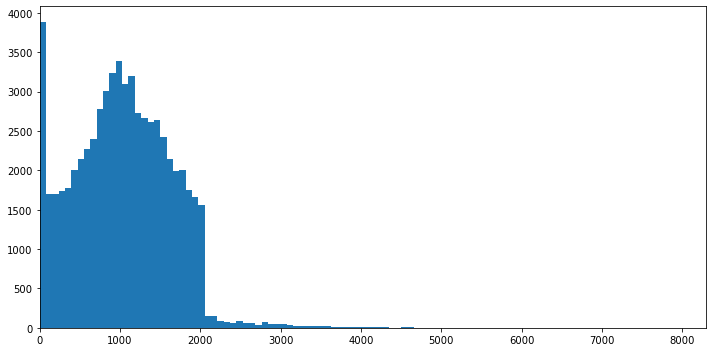

In [25]:
# hist distances (pre-cleaning)
fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

ax.hist(df.distance, bins = 100)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
plt.show()

In [26]:
# remove noises (trips shorter than 52 meters or longer than 1956 meters)
df = df.loc[(df.distance > 52) & (df.distance < 1956)].reset_index(drop=True)

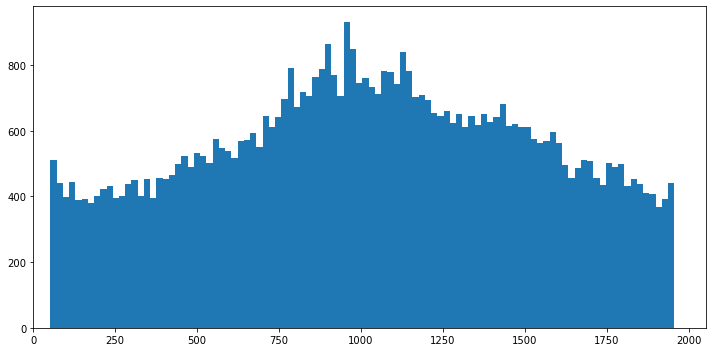

In [27]:
# hist distances after removing extreme observations
fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

ax.hist(df.distance, bins = 100)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
plt.show()

In [28]:
df['lat'] = [df.at[i,'end_pt'][0] for i in range(len(df))]
df['lon'] = [df.at[i,'end_pt'][1] for i in range(len(df))]
df = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.lon, df.lat))

Remove trips ending in free areas:

In [29]:
# remove trips ending in areas where the parking is free/cheaper (soste convenzionate)
area = gpd.read_file("../data/static/punti-sosta-monopattini-con-ordinanza.shp") 
area.head(2)

,note,ordinanza,via,codice,geometry
0,"lato ovest, in prossimità del numero civico 28",n. 1366/2020/27,via Inama,9,POINT (663761.196 5103587.451)
1,"lato ovest, in prossimità del numero civico 38",n. 1366/2020/27,via Rosmini,10,POINT (663867.104 5103679.125)


In [30]:
area = gpd.GeoDataFrame(area, crs='EPSG:32632', geometry=area.geometry) # meters 32632 ita
area['area_buffer'] = area.buffer(5).to_crs(epsg=4326).to_list() # all buffers (polygons in which free/cheaper parking)
area = area.drop(['geometry'], axis=1)


In [31]:
area = gpd.GeoDataFrame(area, crs='EPSG:4326', geometry=area.area_buffer) 

In [32]:
# use R-Tree for getting points inside polygons fast

def intersect_using_spatial_index(source_gdf, intersecting_gdf):
    """
    Conduct spatial intersection using spatial index for candidates GeoDataFrame to make queries faster.
    Note, with this function, you can have multiple Polygons in the 'intersecting_gdf' and it will return all the points 
    intersect with ANY of those geometries.
    """
    source_sindex = source_gdf.sindex
    possible_matches_index = []
    
    # 'itertuples()' function is a faster version of 'iterrows()'
    for other in intersecting_gdf.itertuples():
        bounds = other.geometry.bounds
        c = list(source_sindex.intersection(bounds))
        possible_matches_index += c
    
    # Get unique candidates
    unique_candidate_matches = list(set(possible_matches_index))
    possible_matches = source_gdf.iloc[unique_candidate_matches]

    # Conduct the actual intersect
    result = possible_matches.loc[possible_matches.intersects(intersecting_gdf.unary_union)]
    return result

In [33]:
intersect_using_spatial_index(source_gdf=df, intersecting_gdf=area)

,unique_id,start_time,end_time,distance,speed,start_pt,end_pt,lat,lon,geometry
6162,4594a18b7995_2021-03-06,2021-03-06 13:48:29+00:00,2021-03-06 13:52:49+00:00,430.974258,1.657593,"[46.07684, 11.119618]","[46.073279, 11.118312]",46.073279,11.118312,POINT (11.11831 46.07328)
4123,00001ef5-0000-1000-8dc5-5b7d6a617b60_2021-02-18,2021-02-18 11:52:54+00:00,2021-02-18 12:01:17+00:00,1908.503326,3.794241,"[46.062897, 11.130704]","[46.07518, 11.123853]",46.075180,11.123853,POINT (11.12385 46.07518)
57371,0000002e-0000-1000-886e-5b7d6a617b60_2022-03-04,2022-03-04 17:59:29+00:00,2022-03-04 18:04:03+00:00,944.252747,3.446178,"[46.061244, 11.115899]","[46.065252, 11.122546]",46.065252,11.122546,POINT (11.12255 46.06525)
38945,0000114a-0000-1000-970a-5b7d6a617b60_2021-10-01,2021-10-01 10:44:34+00:00,2021-10-01 10:52:38+00:00,1036.796377,2.142141,"[46.069032, 11.127031]","[46.066238, 11.117487]",46.066238,11.117487,POINT (11.11749 46.06624)
28712,00001f8e-0000-1000-9f9e-5b7d6a617b60_2021-07-28,2021-07-28 06:27:08+00:00,2021-07-28 06:36:31+00:00,1597.695341,2.837825,"[46.061853, 11.126912]","[46.057484, 11.112836]",46.057484,11.112836,POINT (11.11284 46.05748)
...,...,...,...,...,...,...,...,...,...,...
36829,0000039e-0000-1000-818e-5b7d6a617b60_2021-09-21,2021-09-21 11:29:02+00:00,2021-09-21 11:35:03+00:00,1238.215752,3.429961,"[46.058358, 11.122113]","[46.066241, 11.117486]",46.066241,11.117486,POINT (11.11749 46.06624)
24541,00002662-0000-1000-8062-5b7d6a617b60_2021-07-03,2021-07-03 15:17:12+00:00,2021-07-03 15:23:05+00:00,428.431084,1.213686,"[46.065277, 11.122394]","[46.06363, 11.119427]",46.063630,11.119427,POINT (11.11943 46.06363)
4070,00002688-0000-1000-a438-5b7d6a617b60_2021-02-17,2021-02-17 16:47:49+00:00,2021-02-17 17:12:46+00:00,287.100163,0.191784,"[46.063371, 11.123794]","[46.061125, 11.124939]",46.061125,11.124939,POINT (11.12494 46.06112)
40937,00002371-0000-1000-86c1-5b7d6a617b60_2021-10-11,2021-10-11 14:17:24+00:00,2021-10-11 14:22:58+00:00,1651.970247,4.946019,"[46.064848, 11.123168]","[46.057484, 11.112836]",46.057484,11.112836,POINT (11.11284 46.05748)


In [34]:
# drop trips ending inside agreed areas
index_inside_areas = list(intersect_using_spatial_index(source_gdf=df, intersecting_gdf=area).index)
df = df.drop(index_inside_areas).reset_index(drop=True)

### k-dimesional tree 
Associate each origin-destination pair to the closest POIs

In [35]:
# convert to meters --> scipy KDTree works with Euclidean distance
df = df.to_crs(epsg=32632)
df = df.rename(columns = {'geometry':'geo_end'})

df['lat'] = [df.at[i,'start_pt'][0] for i in range(len(df))]
df['lon'] = [df.at[i,'start_pt'][1] for i in range(len(df))]
df = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.lon, df.lat))

df = df.to_crs(epsg=32632)
df = df.rename(columns = {'geometry':'geo_start'})

df = df.drop(['lat', 'lon'], axis=1)

In [36]:
# array of point from the pois dataset
pois_x = []
for p in pois.coords.to_list():
    pois_x.append(p)
pois_x = np.array(pois_x)

# array of points from the trips dataset (points of destination)
trip_x = []
for pt in df.geo_end:
    trip_x.append((pt.x, pt.y))
trip_x = np.array(trip_x)

In [37]:
# fit on POIs points
tree = KDTree(pois_x)

# finds the nearest neighbors among POIs; returns arrays of distances from the nearest neighbour and array of indexes of the nearest neighbour
distance_of_nn, index_of_nn = tree.query(trip_x, 1) 


In [38]:
distance_of_nn, index_of_nn

(array([12.00670959, 19.000146  , 10.01005385, ..., 27.15717691,
        12.5377141 ,  7.58080719]),
 array([1135, 4202,  497, ..., 3218,  228,  728], dtype=int64))

In [39]:
poi_end_primary_tag = []
for i in index_of_nn:
    poi_end_primary_tag.append(pois.at[i, 'primary_category'])
df['poi_end_primary_tag'] = poi_end_primary_tag # the primary category (11 main categories) of the POI near the end pt of trip
df['index_end_poi'] = index_of_nn # the index at which to find the nearest POI in the pois dataset
df['distance_from_end_poi'] = distance_of_nn # the distance from the end pt of trip and its nearest POI

In [40]:
# Repeat the same process with the starting point of e-scooter trips:

# array of points from the trips dataset (starting points of trips)
trip_x = []
for pt in df.geo_start:
    trip_x.append((pt.x, pt.y))
trip_x = np.array(trip_x)

# fit on POIs points
tree = KDTree(pois_x)

# finds the nearest neighbors among POIs; returns arrays of distances from the nearest neighbour and array of indexes of the nearest neighbour
distance_of_nn, index_of_nn = tree.query(trip_x, 1) 

poi_start_primary_tag = []
for i in index_of_nn:
    poi_start_primary_tag.append(pois.at[i, 'primary_category'])
df['poi_start_primary_tag'] = poi_start_primary_tag # the primary category (11 main categories) of the nearest POI to the starting pt of trip
df['index_start_poi'] = index_of_nn # the index at which to find the nearest POI in the pois dataset
df['distance_from_start_poi'] = distance_of_nn # the distance from the starting pt of trip and its nearest POI

### Save the obtained datasets

In [41]:
# fill lon/lat coords where empty (where there was a poly/multipoly) in pois dataset
for i in range(len(pois)):
    if pd.isna(pois.at[i, 'lon']):
        coords = (proj.transform(crs_meters, crs_lonlat, pois.at[i, 'coords'][0], pois.at[i, 'coords'][1])) # to lon/lat
        pois.at[i, 'lon'] = coords[0]
        pois.at[i, 'lat'] = coords[1]

In [866]:
'''
d = df.drop(['geo_end', 'geo_start'], axis=1)
df.to_parquet('../produced_datasets/trip_purpose_data/trip_purposes.parquet')

pois = pois.drop(['geometry'], axis=1)
pois.to_parquet('../produced_datasets/trip_purpose_data/point_of_interest.parquet')
pois.to_parquet('../produced_datasets/trip_purpose_data/point_of_interest.parquet')
'''

In [ ]:
# df = pd.read_parquet('../produced_datasets/trip_purpose_data/trip_purposes.parquet')
# pois = pd.read_parquet('../produced_datasets/trip_purpose_data/point_of_interest.parquet')

### Thresholding
The greater the distance between the point and the nearest POI, the lower the confidence in the association. To eliminate casual association, one must put a threshold on the distance. In order to establish this value, look at how the number of trips increases with distance for the various primary categories of POI.

In [42]:
print('Destination-nearestPOI max, min, avg, median distance:\n',
df.distance_from_end_poi.max(), df.distance_from_end_poi.min(), df.distance_from_end_poi.mean(), df.distance_from_end_poi.median(),
'\nOrigin-nearestPOI max, min, avg, median distance:\n',
df.distance_from_start_poi.max(), df.distance_from_start_poi.min(), df.distance_from_start_poi.mean(), df.distance_from_start_poi.median())

Destination-nearestPOI max, min, avg, median distance:
 264.3189084424064 0.00773668325432366 15.176822825025559 10.33982532632988 
Origin-nearestPOI max, min, avg, median distance:
 223.6404647733707 0.00773668325432366 14.267065254993513 10.094602686463539


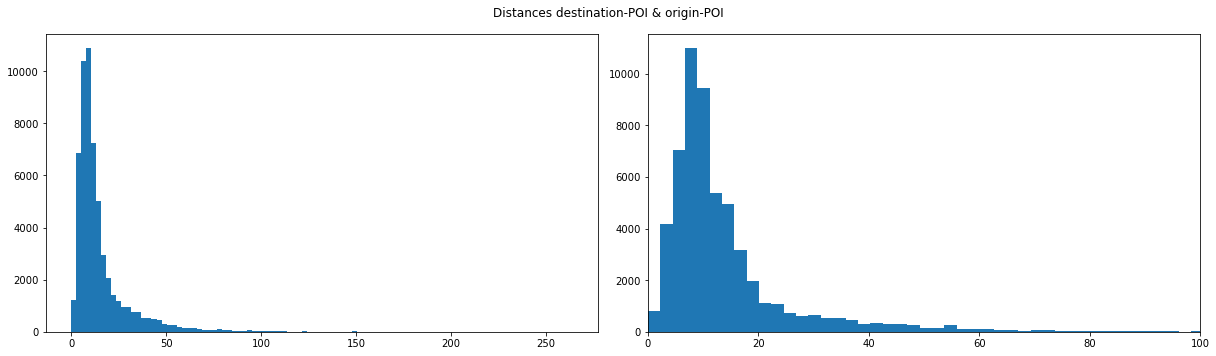

In [43]:
# hist distances destination-POI & origin-POI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(17, 5), tight_layout = True)
fig.suptitle('Distances destination-POI & origin-POI')
ax1.hist(df.distance_from_end_poi, bins = 100)
ax2.hist(df.distance_from_start_poi, bins = 100)
ax2.set_xlim(xmin=0, xmax=100)
ax2.set_xlim(xmin=0, xmax=100)
plt.show()

In [44]:
temp_df = df
temp_df['rounded_dist_end_poi'] = round(df.distance_from_end_poi, 0)
categories_count = temp_df[['poi_end_primary_tag', 'unique_id', 'rounded_dist_end_poi']].groupby(['poi_end_primary_tag', 'rounded_dist_end_poi']).agg(['count'])
categories_count = categories_count.reset_index()
categories_count.columns = categories_count.columns.droplevel(1)
categories_count

,poi_end_primary_tag,rounded_dist_end_poi,unique_id
0,building,0.0,1
1,building,2.0,16
2,building,3.0,180
3,building,4.0,44
4,building,5.0,97
...,...,...,...
943,transport,184.0,1
944,transport,196.0,1
945,transport,204.0,4
946,transport,209.0,1


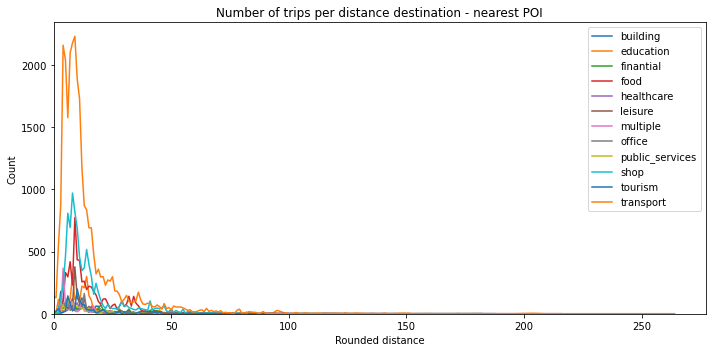

In [45]:
fig, ax = plt.subplots(1, figsize =(10, 5), tight_layout = True)

cat = list(categories_count.poi_end_primary_tag.unique()) # list of primary categories, to plot separately

for c in cat:
    temp_cnt_per_cat = categories_count[categories_count.poi_end_primary_tag==c]
    temp_cnt_per_cat = temp_cnt_per_cat.sort_values(by=['rounded_dist_end_poi']).reset_index(drop=True)
    plt.plot(temp_cnt_per_cat.rounded_dist_end_poi, temp_cnt_per_cat.unique_id)
    plt.legend(cat)

plt.xlabel('Rounded distance')
plt.ylabel('Count')
plt.title('Number of trips per distance destination - nearest POI')
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
plt.show()

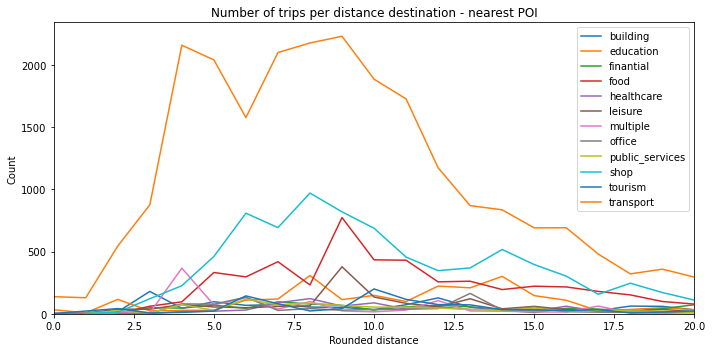

In [46]:
fig, ax = plt.subplots(1, figsize =(10, 5), tight_layout = True)

cat = list(categories_count.poi_end_primary_tag.unique()) # list of primary categories, to plot separately

for c in cat:
    temp_cnt_per_cat = categories_count[categories_count.poi_end_primary_tag==c]
    temp_cnt_per_cat = temp_cnt_per_cat.sort_values(by=['rounded_dist_end_poi']).reset_index(drop=True)
    plt.plot(temp_cnt_per_cat.rounded_dist_end_poi, temp_cnt_per_cat.unique_id)
    plt.legend(cat)

plt.xlabel('Rounded distance')
plt.ylabel('Count')
plt.title('Number of trips per distance destination - nearest POI')
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0, xmax=20)
plt.show()

The main increase of trips-POI association happens **between 0 and 10 meters distance**; outside this range, there is a sharp drop, which means that, after 10 meters distance, the increase in trips-POI association is minimal, and less reliable. 
Interesting enough, there is a huge growth in the association for POI related to transport, which reinforce the idea of e-scooter being used as part of a multi-modal transport modes, to reach other means. Considerable increases are also present for shops and food categories. All other groups present minor fluctuations.

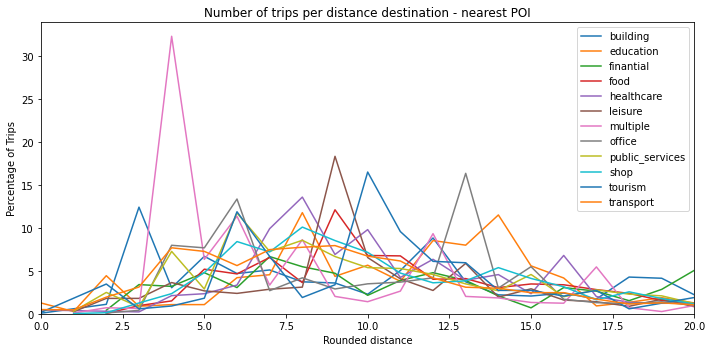

In [47]:
fig, ax = plt.subplots(1, figsize =(10, 5), tight_layout = True)

cat = list(categories_count.poi_end_primary_tag.unique()) # list of primary categories, to plot separately

for c in cat:
    temp_cnt_per_cat = categories_count[categories_count.poi_end_primary_tag==c]
    temp_cnt_per_cat = temp_cnt_per_cat.sort_values(by=['rounded_dist_end_poi']).reset_index(drop=True)
    plt.plot(temp_cnt_per_cat.rounded_dist_end_poi, temp_cnt_per_cat.unique_id*100/temp_cnt_per_cat.unique_id.sum())
    plt.legend(cat)

plt.xlabel('Rounded distance')
plt.ylabel('Percentage of Trips')
plt.title('Number of trips per distance destination - nearest POI')
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0, xmax=20)
plt.show()

Plotting distance over the percentage of trips per categories tells a slightly different story. For lower distances, a high association is shown for POIs belonging to the multiple category, thus being able to serve different purposes at once. Note that the sharp decrease in percentage suggests that the associations correspond to smaller distances, thus should be highly reliable. All other groups present various fluctuations, with several picks.
All in all, there seems to be a declining tendency after 10 meters distance, thus a **threshold = 10** is chosen.

In [48]:
# apply threshold
df = df[df.distance_from_end_poi <= 10].reset_index(drop=True)

In [49]:
df

,unique_id,start_time,end_time,distance,speed,start_pt,end_pt,geo_end,geo_start,poi_end_primary_tag,index_end_poi,distance_from_end_poi,poi_start_primary_tag,index_start_poi,distance_from_start_poi,rounded_dist_end_poi
0,00000e00-0000-1000-9ab0-5b7d6a617b60_2020-11-30,2020-11-30 16:04:42+00:00,2020-11-30 16:12:06+00:00,1445.704719,3.256092,"[46.069695, 11.121283]","[46.081532, 11.121218]",POINT (664008.038 5105293.709),POINT (664048.150 5103978.686),transport,7751,9.298260,transport,787,4.933522,9.0
1,00000eae-0000-1000-9a4e-5b7d6a617b60_2020-11-30,2020-11-30 17:55:53+00:00,2020-11-30 18:06:58+00:00,374.912269,0.563778,"[46.070162, 11.120418]","[46.070105, 11.124537]",POINT (664298.575 5104030.958),POINT (663979.873 5104028.789),food,1410,8.394118,education,7476,14.611021,8.0
2,00001a3f-0000-1000-a1ef-5b7d6a617b60_2020-11-30,2020-11-30 18:10:23+00:00,2020-11-30 18:16:33+00:00,718.474560,1.941823,"[46.071505, 11.124385]","[46.067441, 11.126708]",POINT (664474.379 5103739.460),POINT (664282.665 5104186.191),leisure,4294,7.252683,transport,1254,10.596183,7.0
3,00002668-0000-1000-9ca8-5b7d6a617b60_2020-11-30,2020-11-30 18:55:57+00:00,2020-11-30 18:59:52+00:00,979.678184,4.168843,"[46.074483, 11.125103]","[46.067166, 11.12629]",POINT (664442.870 5103708.042),POINT (664329.345 5104518.547),food,6724,6.926838,food,2109,13.414870,7.0
4,00000b20-0000-1000-8900-5b7d6a617b60_2020-12-01,2020-12-01 08:23:36+00:00,2020-12-01 08:40:54+00:00,1636.516643,1.576606,"[46.069562, 11.118845]","[46.081555, 11.121205]",POINT (664006.964 5105296.238),POINT (663860.005 5103958.883),transport,7751,8.572956,shop,4089,7.905661,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27186,00002421-0000-1000-9cd1-5b7d6a617b60_2022-03-04,2022-03-04 22:10:23+00:00,2022-03-04 22:17:11+00:00,1379.485011,3.381091,"[46.07638, 11.1185]","[46.068354, 11.123948]",POINT (664258.222 5103835.195),POINT (663813.143 5104715.689),transport,577,3.846392,shop,2454,40.398925,4.0
27187,e32eccfc-41f1-4e0a-bef0-b374237ef8f0_2022-03-04,2022-03-04 22:11:16+00:00,2022-03-04 22:12:48+00:00,345.246268,3.752677,"[46.068738, 11.117104]","[46.069826, 11.119795]",POINT (663932.690 5103990.173),POINT (663727.805 5103863.746),shop,838,7.418141,transport,1630,4.834769,7.0
27188,0000122e-0000-1000-83ae-5b7d6a617b60_2022-03-04,2022-03-04 22:18:50+00:00,2022-03-04 22:29:49+00:00,948.130099,1.438741,"[46.061244, 11.115899]","[46.065365, 11.123254]",POINT (664213.418 5103501.668),POINT (663656.770 5103028.642),food,546,8.849931,transport,4146,10.695654,9.0
27189,00000c1f-0000-1000-a6bf-5b7d6a617b60_2022-03-04,2022-03-04 22:19:43+00:00,2022-03-04 22:26:26+00:00,1057.002915,2.622836,"[46.063361, 11.12368]","[46.069792, 11.122202]",POINT (664118.931 5103991.360),POINT (664252.310 5103279.892),food,568,6.232998,transport,555,9.929530,6.0


### Study categories:

In [50]:
# crosstab: on rows the primary category of the destination, and on columns the categories of the origin
colmap = sns.light_palette("green", as_cmap=True)
pd.crosstab(df['poi_end_primary_tag'], df['poi_start_primary_tag'], margins=True).style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport,All
poi_end_primary_tag,,,,,,,,,,,,,
building,21,24,8,73,11,12,8,6,11,66,23,339,602
education,30,58,14,87,23,24,10,10,19,171,28,459,933
finantial,9,24,12,49,11,16,9,8,2,57,17,250,464
food,47,147,41,257,48,63,45,37,32,407,107,1177,2408
healthcare,3,22,12,41,16,10,6,3,10,58,17,180,378
leisure,8,58,19,60,9,17,11,11,8,121,27,487,836
multiple,12,52,10,93,6,21,6,13,10,133,28,367,751
office,16,20,5,40,2,13,8,4,3,70,14,230,425
public_services,17,24,14,69,14,13,9,6,7,82,15,244,514


The table above reports on columns the primary categories of the POI near the origin of the trip and on rows the one close to the destination. The cells present the counts of trips starting near POIs belonging to the column category and ending around POIs of the row category. This matrix is useful to understand the travelling behavior of people using e-scooters. For example, a high number of trips going from office POI to transport may indicate people use e-scooters after their job to reach a transport service, while the inverse relationship would show people use these means of transport to reach their job, thus e-scooter may have become essential for the mobility of people working in offices in the city. Note that by this observation, it is possible to understand which category of people use these transports as well.
From the crosstab, it is clear the primary usage of e-scooters is to reach other means of transports or parking places, and this holds independently of the origin of the trip. A significant number of trips also has the aim of reaching POI belonging to the food and shop categories. Among these, the greatest majority of trips reaching a shop starts near a transport service, which shows how people may use e-scooters after parking their car or bike or after arriving at the bus station in order to reach a shop and perform the desired purchases. Above the average is also the number of trips going from shop to shop and from food to shop. Concerning trips ending near food POIs, the most relevant relations remain shop-food and transport-food. Surprisingly, trips building-education and transport-education (and trips in the opposite directions) are not particularly frequent. A hypothesis was indeed that young people going to university or school may use these means to go from their residence to their place of education or from school or home to the nearest public transport. However, education POIs as an end point present a high cumulative count considering all starting POIs categories (marginals).

Given that transport, shop and food stand above the rest, these categories are further analyzed.

In [211]:
# percantage of trips by endpt-startpt combinations
pd.crosstab(df['poi_start_primary_tag'], df['poi_end_primary_tag'], margins=True, normalize='index').style.background_gradient(cmap = colmap)

poi_end_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport
poi_start_primary_tag,,,,,,,,,,,,
building,0.033654,0.048077,0.014423,0.075321,0.004808,0.012821,0.019231,0.025641,0.027244,0.150641,0.016026,0.572115
education,0.014769,0.035692,0.014769,0.090462,0.013538,0.035692,0.032000,0.012308,0.014769,0.132923,0.016615,0.586462
finantial,0.013769,0.024096,0.020654,0.070568,0.020654,0.032702,0.017212,0.008606,0.024096,0.177281,0.015491,0.574871
food,0.025436,0.030314,0.017073,0.089547,0.014286,0.020906,0.032404,0.013937,0.024042,0.169686,0.019164,0.543206
healthcare,0.024444,0.051111,0.024444,0.106667,0.035556,0.020000,0.013333,0.004444,0.031111,0.175556,0.024444,0.488889
leisure,0.013636,0.027273,0.018182,0.071591,0.011364,0.019318,0.023864,0.014773,0.014773,0.164773,0.021591,0.598864
multiple,0.020888,0.026110,0.023499,0.117493,0.015666,0.028721,0.015666,0.020888,0.023499,0.195822,0.023499,0.488251
office,0.015504,0.025840,0.020672,0.095607,0.007752,0.028424,0.033592,0.010336,0.015504,0.250646,0.036176,0.459948
public_services,0.026829,0.046341,0.004878,0.078049,0.024390,0.019512,0.024390,0.007317,0.017073,0.185366,0.021951,0.543902


Also looking at percentages, it appears to be clear how the main aim of e-scooters trips is to reach POIs belonging to the transport category, thus it is likely e-scooters are used mostly to commute.

#### Transports

In [51]:
transport = df[df.poi_end_primary_tag == 'transport'].reset_index(drop=True)

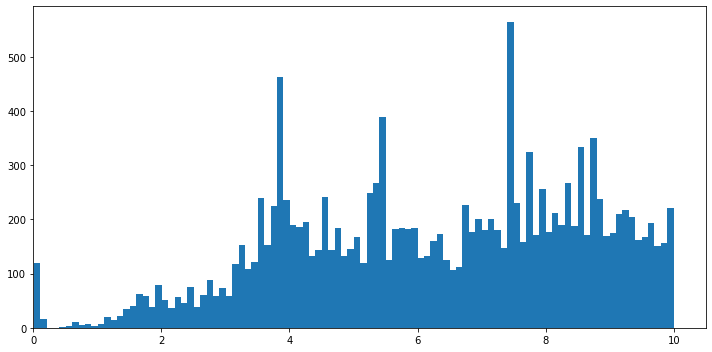

In [52]:
fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

ax.hist(transport.distance_from_end_poi, bins = 100)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
plt.show()

In [54]:
tags_end={}
for i in range(len(transport)):
    pois_index = transport.at[i, 'index_end_poi']
    for col in ['tag1', 'tag2', 'tag3']:
        if pd.isna(pois.at[pois_index, col])==False:
            if pois.at[pois_index, col] in tags_end:
                tags_end[pois.at[pois_index, col]] += 1
            else:
                tags_end[pois.at[pois_index, col]] = 1

In [55]:
tags_end 

{'parking': 4276,
 'bicycle_parking': 6152,
 'parking_space': 3204,
 'motorcycle_parking': 1049,
 'car_sharing': 145,
 'taxi': 15,
 'car_rental': 26,
 'garage': 10,
 'retail': 2,
 'bus_station': 2}

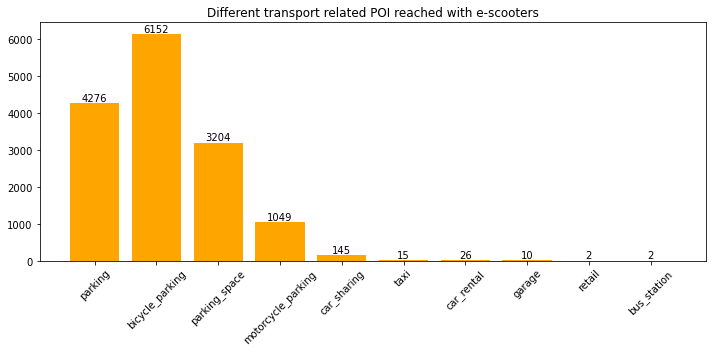

In [56]:
fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

p = plt.bar(tags_end.keys(), tags_end.values(), color='orange')
ax.bar_label(p) # add count over bars
plt.title('Different transport related POI reached with e-scooters')
ax.set_xticklabels(tags_end.keys(), rotation = 45)
plt.show()

In [57]:
# crosstab: on row the primary category of the destination (transport), and on columns all the categories of the origins
pd.crosstab(transport['poi_end_primary_tag'], transport['poi_start_primary_tag']).style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport
poi_end_primary_tag,,,,,,,,,,,,
transport,357,953,334,1559,220,527,187,178,223,2357,500,7474


In [58]:
# get detailed categories
end_main_tag = []
start_main_tag = []
for i in range(len(transport)):
    end_main_tag.append(pois.at[transport.at[i, 'index_end_poi'], 'tag1'])
    start_main_tag.append(pois.at[transport.at[i, 'index_start_poi'], 'tag1'])

In [59]:
# crosstab with details categories: on rows POI types near the origin, on columns POI types near the destination 
# (for all trips with destination primary category "transport")
pd.crosstab(start_main_tag,end_main_tag).style.background_gradient(cmap = colmap)

col_0,bicycle_parking,car_rental,car_sharing,garage,motorcycle_parking,parking,parking_space,retail,taxi
row_0,,,,,,,,,
accountant,6,0,0,0,1,3,2,0,0
administrative,2,0,0,0,0,0,2,0,0
adult_gaming_centre,0,0,0,0,0,1,0,0,0
anime,1,0,0,0,0,1,0,0,0
antiques,0,0,0,0,1,1,2,0,0
apartments,2,0,0,0,1,2,2,0,0
architect,0,0,0,0,0,0,1,0,0
art,31,0,0,0,8,3,5,0,0
artwork,26,0,0,0,7,9,20,0,0


The most frequent origin POI for trips ending in a transport category are parking spaces (for both cars and bikes). This suggests e-scooters are used as an integral part of a multimodal transport chain, to fill the gap between parking places and the next means of transport. Hence, e-scooters provide flexible mode of transportation, which imposes no waiting time if the e-scooter is available. If it is not, the rider may have to choose another, perhaps more expensive, option. All in all, e-scooters seem to be used as a linkage mode, which is both convenient in terms of waiting times and affordable.

#### Shop

In [60]:
shop = df[df.poi_end_primary_tag == 'shop'].reset_index(drop=True)

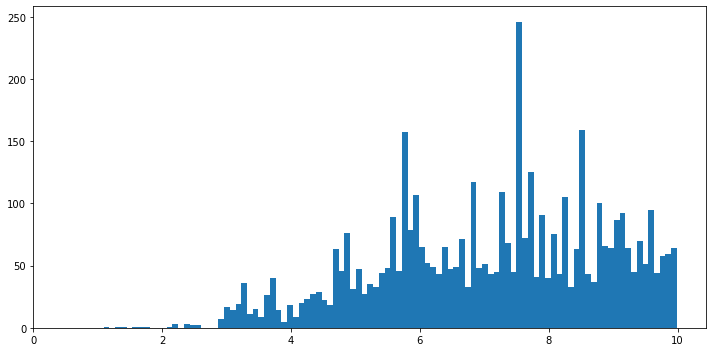

In [62]:
fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

ax.hist(shop.distance_from_end_poi, bins = 100)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
plt.show()

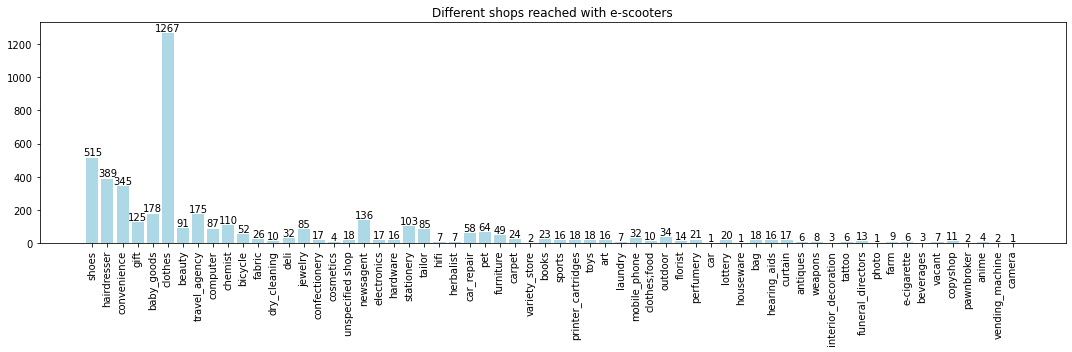

In [68]:
tags_end={}
for i in range(len(shop)):
    pois_index = shop.at[i, 'index_end_poi']
    for col in ['tag1', 'tag2', 'tag3']:
        if pd.isna(pois.at[pois_index, col])==False:
            if pois.at[pois_index, col] in tags_end:
                tags_end[pois.at[pois_index, col]] += 1
            else:
                tags_end[pois.at[pois_index, col]] = 1


fig, ax = plt.subplots(1, 1, figsize =(15, 5), tight_layout = True)

p = plt.bar(tags_end.keys(), tags_end.values(), color='lightblue')
ax.bar_label(p) # add count over bars
plt.title('Different shops reached with e-scooters')
ax.set_xticklabels(tags_end.keys(), rotation = 90)
plt.show()

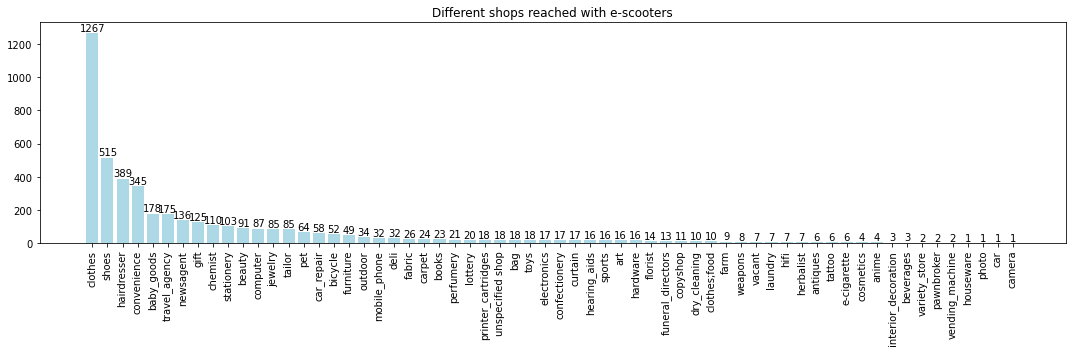

In [71]:
cnt_shop = pd.DataFrame({'shop': tags_end.keys(), 'cnt': tags_end.values()})
cnt_shop = cnt_shop.sort_values(by=['cnt'], ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize =(15, 5), tight_layout = True)

p = plt.bar(cnt_shop.shop, cnt_shop.cnt, color='lightblue')
ax.bar_label(p) # add count over bars
plt.title('Different shops reached with e-scooters')
ax.set_xticklabels(cnt_shop.shop, rotation = 90)
plt.show()

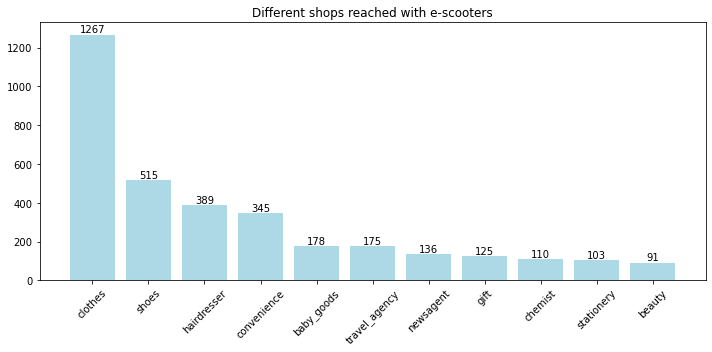

In [74]:
cnt_shop = cnt_shop[cnt_shop.cnt>=90].reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

p = plt.bar(cnt_shop.shop, cnt_shop.cnt, color='lightblue')
ax.bar_label(p) # add count over bars
plt.title('Different shops reached with e-scooters')
ax.set_xticklabels(cnt_shop.shop, rotation = 45)
plt.show()

In [87]:
pd.crosstab(shop['poi_end_primary_tag'], shop['poi_start_primary_tag']).style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport
poi_end_primary_tag,,,,,,,,,,,,
shop,94,216,103,487,79,145,75,97,76,684,180,2220


In [ ]:
# get detailed categories

# end_main_tag = []
# start_main_tag = []
# for i in range(len(shop)):
#     end_main_tag.append(pois.at[shop.at[i, 'index_end_poi'], 'tag1'])
#     start_main_tag.append(pois.at[shop.at[i, 'index_start_poi'], 'tag1'])

# pd.crosstab(start_main_tag, end_main_tag).style.background_gradient(cmap = colmap)

Concerning trips ending nears shops, the greatest majority reaches clothes selling shops, while less than half the count of trips reached shoes shops, hairdressers, and convenience stores. Shops are mainly reached starting from transport places, to go from cars/bikes parking places to the desired shop, and from other shops, which may suggest people use this mobility service during their shopping days, to move quickly among different destinations.
When considering parking-shop trips, one may assume people are in the condition of driving their own car to reach their destination or ride their bike, but no parking lots may be available near the shop of destination and/or the one available may be expensive. E-scooters are a way to alleviate the stress and financial burden of finding a parking area nearby, allowing to stop further away while still being able to reach in no time the desired point. This suggests e-scooters are used as a last mile solution.

#### Food

In [88]:
food = df[df.poi_end_primary_tag == 'food'].reset_index(drop=True)

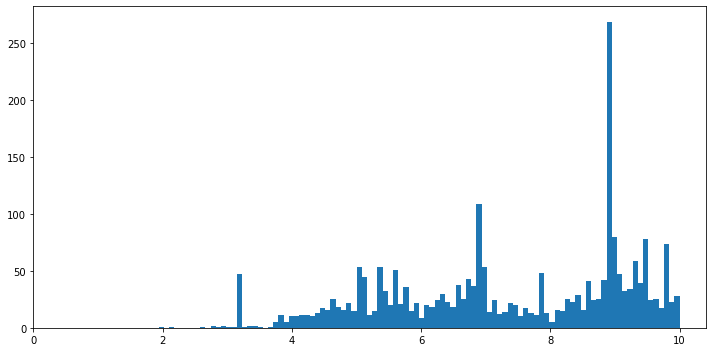

In [89]:
fig, ax = plt.subplots(1, 1, figsize =(10, 5), tight_layout = True)

ax.hist(food.distance_from_end_poi, bins = 100)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
plt.show()

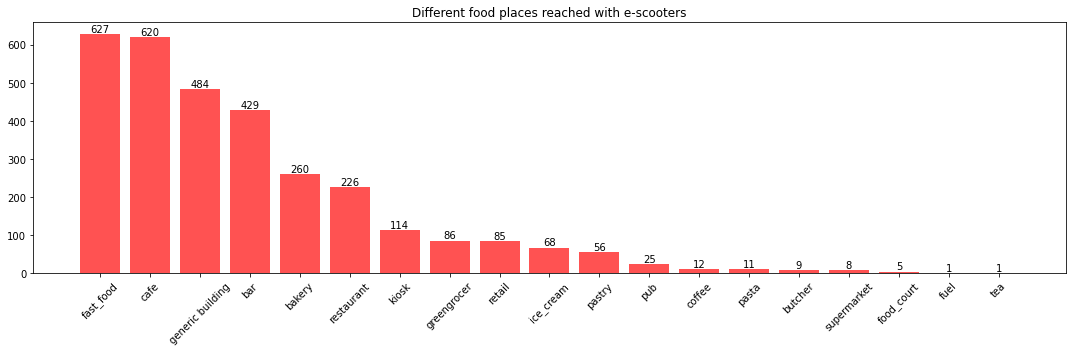

In [95]:
tags_end={}
for i in range(len(food)):
    pois_index = food.at[i, 'index_end_poi']
    for col in ['tag1', 'tag2', 'tag3']:
        if pd.isna(pois.at[pois_index, col])==False:
            if pois.at[pois_index, col] in tags_end:
                tags_end[pois.at[pois_index, col]] += 1
            else:
                tags_end[pois.at[pois_index, col]] = 1


cnt_food = pd.DataFrame({'food': tags_end.keys(), 'cnt': tags_end.values()})
cnt_food = cnt_food.sort_values(by=['cnt'], ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize =(15, 5), tight_layout = True)

p = plt.bar(cnt_food.food, cnt_food.cnt, color='#ff5252')
ax.bar_label(p) # add count over bars
plt.title('Different food places reached with e-scooters')
ax.set_xticklabels(cnt_food.food, rotation = 45)
plt.show()

In [96]:
pd.crosstab(food['poi_end_primary_tag'], food['poi_start_primary_tag']).style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport
poi_end_primary_tag,,,,,,,,,,,,
food,47,147,41,257,48,63,45,37,32,407,107,1177


For what concerns trips ending nearby food POI, the greatest majority end up near bars or cafe, which in the context of Trento may be considered as a single category, thus recording the highest cumulative count. Next is the fast-food sub-category, which record a quite high number of trips ending nearby. As mentioned above, the greatest usage of e-scooter is as a last-mile means of transport, in order to reach from parking places or from the bus stations, the final destination, which in this case are mostly cafes and bars and may be linked to leisure purposes.

### Temporal considerations
Check if the main trip purposes change by time of the day.

See how trips purposes change by time of the week (weekend vs. working days):

In [193]:
days = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df['weekday'] = [days[df.at[i,'start_time'].weekday()] for i in range(len(df))]
weekend_df = df[df.weekday.isin(['Saturday', 'Sunday'])].reset_index(drop=True)
weekday_df = df[df.weekday.isin(['Saturday', 'Sunday'])==False].reset_index(drop=True)

In [207]:
# trips POI origin-destination on WEEKENDS
pd.crosstab(weekend_df['poi_end_primary_tag'], weekend_df['poi_start_primary_tag'], margins=True).style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport,All
poi_end_primary_tag,,,,,,,,,,,,,
building,3,7,1,13,3,3,1,3,7,10,6,92,149
education,9,13,3,16,6,3,1,2,1,48,5,97,204
finantial,2,4,2,14,3,5,3,2,0,16,2,67,120
food,17,32,9,49,9,17,14,10,6,101,18,280,562
healthcare,1,5,2,8,3,2,2,1,2,12,4,38,80
leisure,3,13,2,16,2,1,2,4,4,22,5,131,205
multiple,4,15,2,26,3,6,1,4,2,25,5,87,180
office,4,5,1,9,0,5,3,0,0,20,3,52,102
public_services,4,10,1,9,5,0,2,3,1,22,5,69,131


In [208]:
# trips POI origin-destination on WEEKDAYS
pd.crosstab(weekday_df['poi_end_primary_tag'], weekday_df['poi_start_primary_tag'], margins=True).style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport,All
poi_end_primary_tag,,,,,,,,,,,,,
building,18,17,7,60,8,9,7,3,4,56,17,247,453
education,21,45,11,71,17,21,9,8,18,123,23,362,729
finantial,7,20,10,35,8,11,6,6,2,41,15,183,344
food,30,115,32,208,39,46,31,27,26,306,89,897,1846
healthcare,2,17,10,33,13,8,4,2,8,46,13,142,298
leisure,5,45,17,44,7,16,9,7,4,99,22,356,631
multiple,8,37,8,67,3,15,5,9,8,108,23,280,571
office,12,15,4,31,2,8,5,4,3,50,11,178,323
public_services,13,14,13,60,9,13,7,3,6,60,10,175,383


Trips purposes patterns seem to be similar in weekends and weekdays: given that the main purpose of e-scooters is to commute to another means of transport and this is not something typical of weekdays only, the same pattern remains. As far as food and shops are concerns, there are still similar patterns. As expected, during weekends there is a decline in the absolute number of trips directed to educational areas, such as schools and university.

In [214]:
# weekdays
pd.crosstab(weekday_df['poi_end_primary_tag'], weekday_df['poi_start_primary_tag'], margins=True, normalize='index').style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport
poi_end_primary_tag,,,,,,,,,,,,
building,0.039735,0.037528,0.015453,0.132450,0.017660,0.019868,0.015453,0.006623,0.008830,0.123620,0.037528,0.545254
education,0.028807,0.061728,0.015089,0.097394,0.023320,0.028807,0.012346,0.010974,0.024691,0.168724,0.031550,0.496571
finantial,0.020349,0.058140,0.029070,0.101744,0.023256,0.031977,0.017442,0.017442,0.005814,0.119186,0.043605,0.531977
food,0.016251,0.062297,0.017335,0.112676,0.021127,0.024919,0.016793,0.014626,0.014085,0.165764,0.048212,0.485915
healthcare,0.006711,0.057047,0.033557,0.110738,0.043624,0.026846,0.013423,0.006711,0.026846,0.154362,0.043624,0.476510
leisure,0.007924,0.071315,0.026941,0.069731,0.011094,0.025357,0.014263,0.011094,0.006339,0.156894,0.034865,0.564184
multiple,0.014011,0.064799,0.014011,0.117338,0.005254,0.026270,0.008757,0.015762,0.014011,0.189142,0.040280,0.490368
office,0.037152,0.046440,0.012384,0.095975,0.006192,0.024768,0.015480,0.012384,0.009288,0.154799,0.034056,0.551084
public_services,0.033943,0.036554,0.033943,0.156658,0.023499,0.033943,0.018277,0.007833,0.015666,0.156658,0.026110,0.456919


In [216]:
# weekends
pd.crosstab(weekend_df['poi_end_primary_tag'], weekend_df['poi_start_primary_tag'], margins=True, normalize='index').style.background_gradient(cmap = colmap)

poi_start_primary_tag,building,education,finantial,food,healthcare,leisure,multiple,office,public_services,shop,tourism,transport
poi_end_primary_tag,,,,,,,,,,,,
building,0.020134,0.046980,0.006711,0.087248,0.020134,0.020134,0.006711,0.020134,0.046980,0.067114,0.040268,0.617450
education,0.044118,0.063725,0.014706,0.078431,0.029412,0.014706,0.004902,0.009804,0.004902,0.235294,0.024510,0.475490
finantial,0.016667,0.033333,0.016667,0.116667,0.025000,0.041667,0.025000,0.016667,0.000000,0.133333,0.016667,0.558333
food,0.030249,0.056940,0.016014,0.087189,0.016014,0.030249,0.024911,0.017794,0.010676,0.179715,0.032028,0.498221
healthcare,0.012500,0.062500,0.025000,0.100000,0.037500,0.025000,0.025000,0.012500,0.025000,0.150000,0.050000,0.475000
leisure,0.014634,0.063415,0.009756,0.078049,0.009756,0.004878,0.009756,0.019512,0.019512,0.107317,0.024390,0.639024
multiple,0.022222,0.083333,0.011111,0.144444,0.016667,0.033333,0.005556,0.022222,0.011111,0.138889,0.027778,0.483333
office,0.039216,0.049020,0.009804,0.088235,0.000000,0.049020,0.029412,0.000000,0.000000,0.196078,0.029412,0.509804
public_services,0.030534,0.076336,0.007634,0.068702,0.038168,0.000000,0.015267,0.022901,0.007634,0.167939,0.038168,0.526718


Looking at percentage, one may notice that during weekdays, people mostly use e-scooters to go from a parking place or station to their residence, office, or place of leisure. Not surpisingly, on weekends, starting from transport POI, e-scooters are used to reach mostly leisure places and residential areas. In some sense, the percentage show the slightly different rithm of life people adopt through the weekends and the different habits they have.

See how trips purposes change by hours of the day:

In [109]:
df['start_hour'] = [df.at[i, 'start_time'].hour for i in range(len(df))]

In [117]:
df[['start_hour']].quantile([.25, .5, .75, 1], interpolation='nearest', numeric_only=False)

,start_hour
0.25,10
0.50,13
0.75,17
1.00,23


Trips are distributed quite differently by time of the day, with the greatest concentration of trips between 10am and 13pm, which means that in a shorter time (3 hours), a number of trips equal to the ones reached in several more hours during other times of the day (respectively, 10 hours in the morning, 4 in the afternoon and 6 at night) is reached.

In [122]:
cnt_by_h = df[['unique_id', 'start_hour']].groupby(['start_hour']).agg(['count']).reset_index()
cnt_by_h.columns = cnt_by_h.columns.droplevel(1)

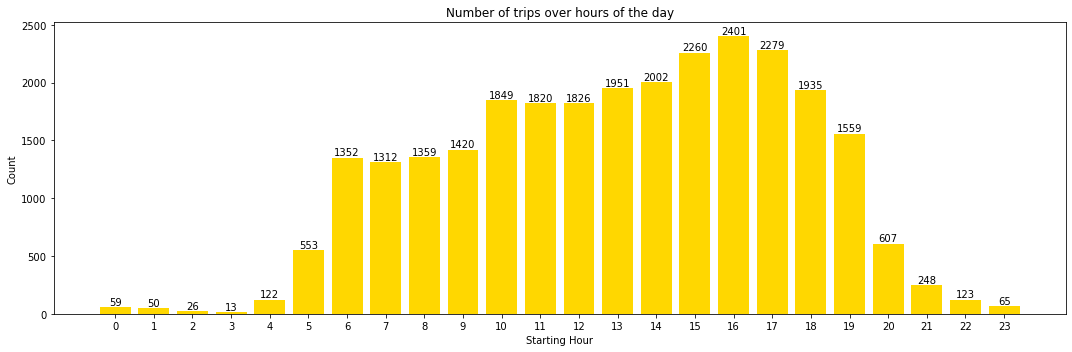

In [138]:
fig, ax = plt.subplots(1, 1, figsize =(15, 5), tight_layout = True)

p = plt.bar(cnt_by_h.start_hour, cnt_by_h.unique_id, color='gold')
ax.bar_label(p) 
plt.title('Number of trips over hours of the day')
ax.set_xticks(cnt_by_h.start_hour)
ax.set_xlabel('Starting Hour')
ax.set_ylabel('Count')
plt.show()

Given that trips distribute differently over the times of the day, one may wonder if there is also a linkage between the time and the purpose of the run. To explore the relationship between trip purpose and time of the day, the dataset is divided into 4 equally wide time-window according to the starting time of the trip. Each window is 6 hours long.

In [322]:
for i in range(len(df)):
    if df.at[i, 'start_hour'] <= 6:
        df.at[i, 'timewindow'] = '0am - 6am'
    elif df.at[i, 'start_hour'] > 6 and df.at[i, 'start_hour'] <= 12:
        df.at[i, 'timewindow'] = '6am - 12pm'
    elif df.at[i, 'start_hour'] > 12 and df.at[i, 'start_hour'] <= 18:
        df.at[i, 'timewindow'] = '12pm - 6pm'
    elif df.at[i, 'start_hour'] > 18:
        df.at[i, 'timewindow'] = '6pm - 0am'

In [321]:
pd.crosstab(df['poi_start_primary_tag'], [df['timewindow'], df['poi_end_primary_tag']]).style.background_gradient(cmap = colmap)

In [323]:
def table_by_timerange(qnt):
    qnt_df = df.loc[df['timewindow'] == qnt]

    end_cnt = qnt_df[['poi_end_primary_tag', 'unique_id']].groupby(['poi_end_primary_tag']).agg(['count']).reset_index()
    end_cnt.columns = end_cnt.columns.droplevel(1)
    end_cnt = end_cnt.rename(columns={"unique_id": "destination"})

    start_cnt = qnt_df[['poi_start_primary_tag', 'unique_id']].groupby(['poi_start_primary_tag']).agg(['count']).reset_index()
    start_cnt.columns = start_cnt.columns.droplevel(1)
    start_cnt = start_cnt.rename(columns={"unique_id": "origin", "poi_start_primary_tag": "categories"})
    start_cnt

    result = pd.concat([start_cnt, end_cnt], axis=1)
    result = result.drop(['poi_end_primary_tag'], axis=1)
    result['time_level'] = qnt
    result = result.set_index('time_level', append=True).unstack('time_level')
    return result


first = table_by_timerange('0am - 6am')
second = table_by_timerange('6am - 12pm')
third = table_by_timerange('12pm - 6pm')
fourth = table_by_timerange('6pm - 0am') 

In [324]:
pd.concat([first, second, third, fourth], axis=1).style.background_gradient(cmap = colmap)

,categories,origin,destination,categories,origin,destination,categories,origin,destination,categories,origin,destination
time_level,0am - 6am,0am - 6am,0am - 6am,6am - 12pm,6am - 12pm,6am - 12pm,12pm - 6pm,12pm - 6pm,12pm - 6pm,6pm - 0am,6pm - 0am,6pm - 0am
0,building,41,55,building,236,230,building,306,270,building,41,47
1,education,108,113,education,594,323,education,782,430,education,141,67
2,finantial,33,36,finantial,239,181,finantial,267,205,finantial,42,42
3,food,246,171,food,997,812,food,1294,1138,food,333,287
4,healthcare,29,28,healthcare,179,138,healthcare,197,169,healthcare,45,43
5,leisure,96,67,leisure,299,350,leisure,416,360,leisure,69,59
6,multiple,31,42,multiple,135,243,multiple,180,388,multiple,37,78
7,office,28,45,office,134,152,office,187,197,office,38,31
8,public_services,26,50,public_services,177,194,public_services,175,216,public_services,32,54


Categories show relatively similar prevalence/pattern within the same time-window, when comparing origins and destinations; the main difference is the the magnitude of the counts, namely the concentration of the number of trips in some time-windows more than others. Picks are shown between 12pm and 6pm, as generally visible also in the histogram above. All in all, the number of trips increases throughout the day and there is an overall lack of symmetry in rides between the early and later hours, with the latter presenting higher concentration of trips.